In [52]:
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Colours for matrix visualization.
binary_pal= ["#F5E5FC","#1F487E"]
bin_cmap = LinearSegmentedColormap.from_list('Custom', binary_pal, len(binary_pal))

# PLANTED SUBMATRIX

In [190]:
def plantedsubmatrix(M,N,m,n,p,q):
    '''
    PLANTEDSUBMATRIX Makes binary matrix A with planted mn-submatrix.
    
    Generates mn-submatrix with expected density q in MxN matrix A with
    expected densities of remaining entries equal to q.
    
    INPUT:
        M,N - desired dimensions of A.
        m,n - desired dimensions of planted submatrix.
        p - desired noise density.
        q - desired in-group density.
    
    OUTPUT:
        A - matrix containing desired planted submatrix.
        X0, Y0 - matrix representation of the planted submatrix.
    '''

    # Imports
    from numpy.random import rand
    from numpy import ceil, ones, zeros

    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # GENERATE NOISE ENTRIES OF A.
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Initialize A as uniform random matrix.
    tmp = rand(M,N)

    # Round entries of A to 0 if less than 1-p and up to 1 otherwise.
    A = ceil(tmp-(1-p))

    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # FILL IN DENSE BLOCK.
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Repeat with mn-block and threshhold 1-q.
    tmp = rand(m,n)
    A[:m, :n] = ceil(tmp-(1-q))

    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # CALCULATE MATRIX REPRESENTATION OF PLANTED SUBMATRIX.
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # X0
    X0 = zeros((M,N))
    X0[:m,:n] = ones((m,n))

    # Y0
    Y0 = zeros((M,N))
    Y0[:m,:n] = ones((m,n)) - A[:m,:n]
    
    # Return A, X0, Y0.
    return(A, X0, Y0)
# end plantedsubmatrix.

# Soft Thresholding

In [54]:
def soft_thresh(a,t):
    from numpy import maximum as nmax
    return(nmax(0, a-t) - nmax(0,-a-t))

# Probability Simplex

In [245]:
def prob_simplex(y0, k):
    from numpy import zeros, ones, sort, argsort, cumsum, concatenate, inf
    n = len(y0)
    
    
    if (k<0) or (k > n):
        raise ValueError("The sum constraint is infeasible!")
    
    if k==n:
        x = ones(n)
        return(x)
    elif k==0:
        x = zeros(n) 
        return(x)
    else:
        x = zeros(n) 
        idx = argsort(y0)
        y = y0[idx]

        s = cumsum(y)
        y = concatenate((y, np.array([inf])))
        
        # print(y)
        #+++++++++++++++++++++++++++++++++++
        # a = b = integers case.
        #+++++++++++++++++++++++++++++++++++
        if k==round(k):
            b=n-k
            # print(b)
            # print(y[b+1]-y[b])
            if y[b]-y[b-1]>=1:
                x[idx[b:]]=1
                return(x)
            # print(x)
    

        #+++++++++++++++++++++++++++++++++++
        # a = 0
        #+++++++++++++++++++++++++++++++++++       
        for b in range(n):
            # hypothesised gamma
            gamma = (k+b+1 - n - s[b])/(b+1)

            if ((y[0] + gamma) > 0) and ((y[b]+gamma) < 1) and ((y[b+1] + gamma) >= 1):
                # print(y[0:b])
                xtmp = concatenate((y[0:b+1] + gamma, ones(n-b-1)))
                x[idx]=xtmp
                return(x)
        
        #+++++++++++++++++++++++++++++++++++
        # a >= 1
        #+++++++++++++++++++++++++++++++++++
        for a in range(n):
            for b in range(a+1,n):
                # hypothesised gamma.
                gamma = (k + b + 1 - n + s[a] - s[b])/(b-a)

                if ((y[a]+gamma) <= 0) and ((y[a+1] + gamma) > 0) and ((y[b]+gamma)<1) and ((y[b+1] + gamma) >= 1):
                    
                    xtmp = concatenate((zeros(a+1), y[a+1:b+1] + gamma, ones(n-b-1)))
                    x[idx] = xtmp
                    return(x)                   



## DEBUG PROB_SIMPLEX

In [104]:
a = [1, -3, -2, -0.5, 0.5, 0.75]
k = 3

print(prob_simplex(a, k))

[-3.   -2.   -0.5   0.5   0.75  1.     inf]
3
0.25
[1. 0. 0. 0. 1. 1.]


# ENSUB

In [434]:
class ENSub:
    """
    Class for solving the mn-submatrix problem using the alternating direction method of multipliers for solving non-convex QP relaxation.

    Methods:
        constructor(tau, opt_tol, maxiters, verbose):
            define optimization parameters.
        solve(A,m,n,gamma): 
            solver for instance of problem with data matrix A, desired submatrix size (m,n), and regularization parameter gamma.
    Data attributes:
        rho: augmented Lagrangian penalty parameter.
        opt_tol: desired suboptimality stopping tolerance.
        maxiter: maximum number of iterations to perform.
        verbose: boolean, indicates whether to display iteration statistics.       
    """

     # Constructor.
    def __init__(self, rho=1, alpha=0.5, opt_tol=1e-4, maxiter=1000, symmetric=False, verbose=False):
        self.rho = rho
        self.alpha = alpha
        self.opt_tol = opt_tol
        self.maxiter = maxiter
        self.symmetric = symmetric
        self.verbose = verbose
    # end constructor.

    # Solver function - unsymmetric case.
    def unsym_solve(self, A, mm, gamma):
        # imports
        from numpy import zeros, concatenate, block
        from numpy import sum as nsum        
        from numpy.linalg import norm

        #++++++++++++++++++++++++++++++++++++++++++++
        # Initialisation.
        #++++++++++++++++++++++++++++++++++++++++++++++
        # Get dimensions of A.
        M,N = A.shape

        m,n = mm[0], mm[1]

        # Initial solutions.
        u0 = nsum(A,1)
        u = m*u0/nsum(u0)
        # print(u0.shape)
        v0 = nsum(A,0)
        v = n*v0/nsum(v0)
        # print(v0.shape)

        y = concatenate((u,v))
        x = y 
        lambs = zeros(M + N)

        # Make coefficient matrix Q.
        Abar = 1 - A
        Q = block([
            [zeros((M,M)), Abar],
            [Abar.T, zeros((N,N))]
        ])

        iters = 0
        not_converged=True
        rhohat = self.rho + 1 - self.alpha

        #++++++++++++++++++++++++++++++++++++++++++++++
        # Iterate until maxits performed or converged.
        #++++++++++++++++++++++++++++++++++++++++++++++
        # Iteration stats table.
        if self.verbose:
            head_length=55      
            print("+"*head_length)
            print("ENSUB - ADMM for Elastic Net Densest Submatrix")
            print("+"*head_length)
            print(f"M={M:d}, N={N:d}, m={m:d}, n={n:d}, gamma={gamma:1.3e}")
            print("+"*head_length)
            print("It \t | Objective \t | Primal Gap \t | Dual \t")
            print("+"*head_length)

        

        while not_converged and (iters < self.maxiter):
            # Increment iteration counter.
            iters+=1  

            # Update x via soft-thresholding.
            xold = x             
            x = soft_thresh(
                a=(self.rho*y - lambs - Q @ y)/rhohat, 
                t=gamma*self.alpha/self.rho
            )

            # Update u,v,y via projection onto the capped probability simplex.
            yold = y 
            u = prob_simplex(
                y0= x[:M] - (Abar @ x[M:] + lambs[:M])/self.rho, 
                k = m 
            )
            v = prob_simplex(
                y0= x[M:] - (Abar.T @ x[:M] + lambs[M:])/self.rho,
                k = n
            )
            # print(u.shape)
            # print(v.shape)
            y = concatenate((u,v))

            # Update lambda by dual gradient ascent. 
            lambs = lambs + self.rho*(x - y) 

            # Check for convergence. 
            pfeas = norm(x - y)/norm(x) 
            dfeas = max(
                norm(xold - x)/norm(xold), 
                norm(yold - y)/norm(yold)
            )
            fval = gamma*(self.alpha*norm(x,1) + (1-self.alpha)/2*norm(x,2)**2) + 0.5*y.T @ Q @ y 

            if dfeas < self.opt_tol and pfeas < self.opt_tol: # CONVERGED!!
                not_converged = False

            #++++++++++++++++++++++++++++++++++++++++++
            # Display iteration statistics if verbose.            
            #++++++++++++++++++++++++++++++++++++++++++
            
            if self.verbose: 
                if (iters % 5) == 0:
                    print("%3d \t | %1.3e \t | %1.3e \t | %1.3e" %(iters, fval, pfeas, dfeas))

        return(u,v, x, y, fval, iters)
    # End Unsymmetric_Solve

    # Symmetric solver.
    def sym_solve(self, A, m, gamma):
        # imports
        from numpy import zeros, concatenate, block
        from numpy import sum as nsum        
        from numpy.linalg import norm

        # Get size of A.
        M = A.shape[0]

        # Initial solutions.
        x0 = nsum(A,1)
        x = m*x0/nsum(x0)

        y = x
        lambs = zeros(M)

        # Coefficient matrix.
        Abar = 1 - A

        # Parameters.
        iters = 0
        not_converged=True
        rhohat = self.rho + 1 - self.alpha

        #++++++++++++++++++++++++++++++++++++++++++++++
        # Iterate until maxits performed or converged.
        #++++++++++++++++++++++++++++++++++++++++++++++
        # Iteration stats table.
        if self.verbose:
            head_length=55      
            print("+"*head_length)
            print("ENSUB - ADMM for Elastic Net Densest Submatrix")
            print("+"*head_length)
            print("Symmetric -- " + f"M={M:d}, m={m:d}, gamma={gamma:1.3e}")
            print("+"*head_length)
            print("It \t | Objective \t | Primal Gap \t | Dual \t")
            print("+"*head_length)        

        while not_converged and (iters < self.maxiter):
            # Increment iteration counter.
            iters+=1  

            # Update x via soft-thresholding.
            xold = x   
            x = soft_thresh(
                a=(self.rho*y - lambs - Abar @ y)/rhohat, 
                t=gamma*self.alpha/self.rho
            )

            # Update y via projection onto the capped probability simplex.
            yold = y 
            y = prob_simplex(
                y0= x + (-Abar @ x + lambs)/self.rho, 
                k = m 
            )

            # Update lambda by dual gradient ascent. 
            lambs = lambs + self.rho*(x - y) 

            # Check for convergence. 
            pfeas = norm(x - y)/norm(x) 
            dfeas = max(
                norm(xold - x)/norm(xold), 
                norm(yold - y)/norm(yold)
            )
            fval = gamma*(self.alpha*norm(x,1) + (1-self.alpha)/2*norm(x,2)**2) + x.T @ Abar @ x / 2 

            if dfeas < self.opt_tol and pfeas < self.opt_tol: # CONVERGED!!
                not_converged = False

            #++++++++++++++++++++++++++++++++++++++++++
            # Display iteration statistics if verbose.            
            #++++++++++++++++++++++++++++++++++++++++++
            
            if self.verbose: 
                if (iters % 5) == 0:
                    print("%3d \t | %1.3e \t | %1.3e \t | %1.3e" %(iters, fval, pfeas, dfeas))

        return(x, y, fval, iters)
    # End symmetric solver.

    # General solve function.
    def solve(self, A, mm, gamma):
        if self.symmetric:
            return(self.sym_solve(A, mm, gamma))
        else:
            return(self.unsym_solve(A, mm, gamma))

# End ENSub class

            

## Examples

We illustrate use of this package on three different types of data: 

1. Using random matrices sampled from the planted dense $m \times n$ submatrix model; 

2. Using random adjacency matrices of random graphs sampled from the planted dense subgraph model;  

3. Using a real-world collaboration network.

### Random Matrices

We generate a random matrix with noise obscuring the planted submatrix using the function ``plantedsubmatrix`` and then use the solver from the ``ENSub`` class to recover the planted submatrix.

In [271]:
# Dimensions of the full matrix.
M, N = 60, 50

# Dimensions of the dense block.
m, n = 30, 20

# In-group and noise density.
q, p = 0.75, 0.25

# Make binary matrix with planted mn-submatrix
A, X0, Y0 = plantedsubmatrix(M,N,m,n,p,q)

After generating the random matrix with desired planted structure, we can visually represent the matrix and planted submatrix as two-tone images, where dark pixels correspond to nonzero entries, and light pixels correspond to zero entries.

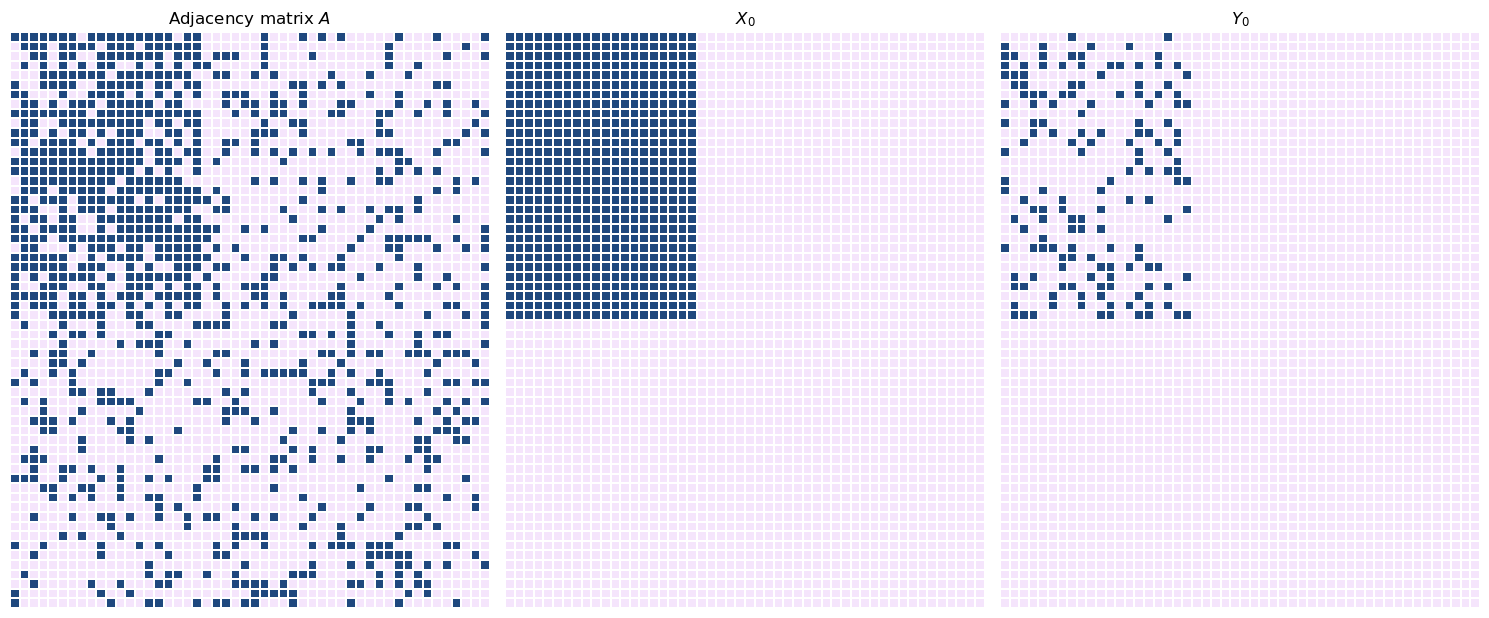

In [272]:
fig, axes = plt.subplots(1,3)
fig.set_size_inches(15, 15)

plt.subplot(1,3,1)
sns.heatmap(A, linewidth =0.01, cbar=False, square=True, cmap=bin_cmap)
axes[0].set_axis_off()
axes[0].set_title("Adjacency matrix $A$")

plt.subplot(1,3,2)
sns.heatmap(X0, linewidth =.01, cbar=False, square=True, cmap=bin_cmap)
axes[1].set_axis_off()
axes[1].set_title("$X_0$")

plt.subplot(1,3,3)
sns.heatmap(Y0, linewidth =.01, cbar=False, square=True, cmap=bin_cmap)
axes[2].set_axis_off()
axes[2].set_title("$Y_0$")

plt.box(False)
plt.tight_layout()

plt.savefig("DEMO/planted_submatrix.png", transparent = False, bbox_inches="tight")
plt.show()

The vizualization of the randomly generated matrix  helps us to understand its structure. It is clear that it contains a dense 30 x 20 block (top left corner).

We call our solver with `verbose=True` and otherwise default settings. We choose 
$$
    \gamma = \frac{(q-p) \min \{m,n\}}{10}.
$$
as suggested in the paper.

In [296]:
es = ENSub(rho=1, opt_tol=1e-8, verbose=True)
gam = (q-p)*np.sqrt(m*n)/10
u,v, x, y, fval, its = es.solve(A, m, n, gam)

+++++++++++++++++++++++++++++++++++++++++++++++++++++++
ENSUB - ADMM for Elastic Net Densest Submatrix
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
M=60, N=50, m=30, n=20, gamma=1.225e+00
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
It 	 | Objective 	 | Primal Gap 	 | Dual 	
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
  5 	 | 4.885e+02 	 | 9.696e-01 	 | 6.897e-01
 10 	 | 6.609e+02 	 | 8.343e-01 	 | 2.901e+00
 15 	 | 2.048e+02 	 | 7.176e-02 	 | 1.267e-01
 20 	 | 1.999e+02 	 | 3.158e-04 	 | 6.312e-04
 25 	 | 1.999e+02 	 | 1.300e-06 	 | 2.600e-06
 30 	 | 1.999e+02 	 | 5.349e-09 	 | 1.070e-08


The ``ENSub`` solver returns vectors $x=y$ containing the characteristic vectors of the rows and columns of the dense submatrix.

We can extract these and visualise the index set of the planted submatrix.

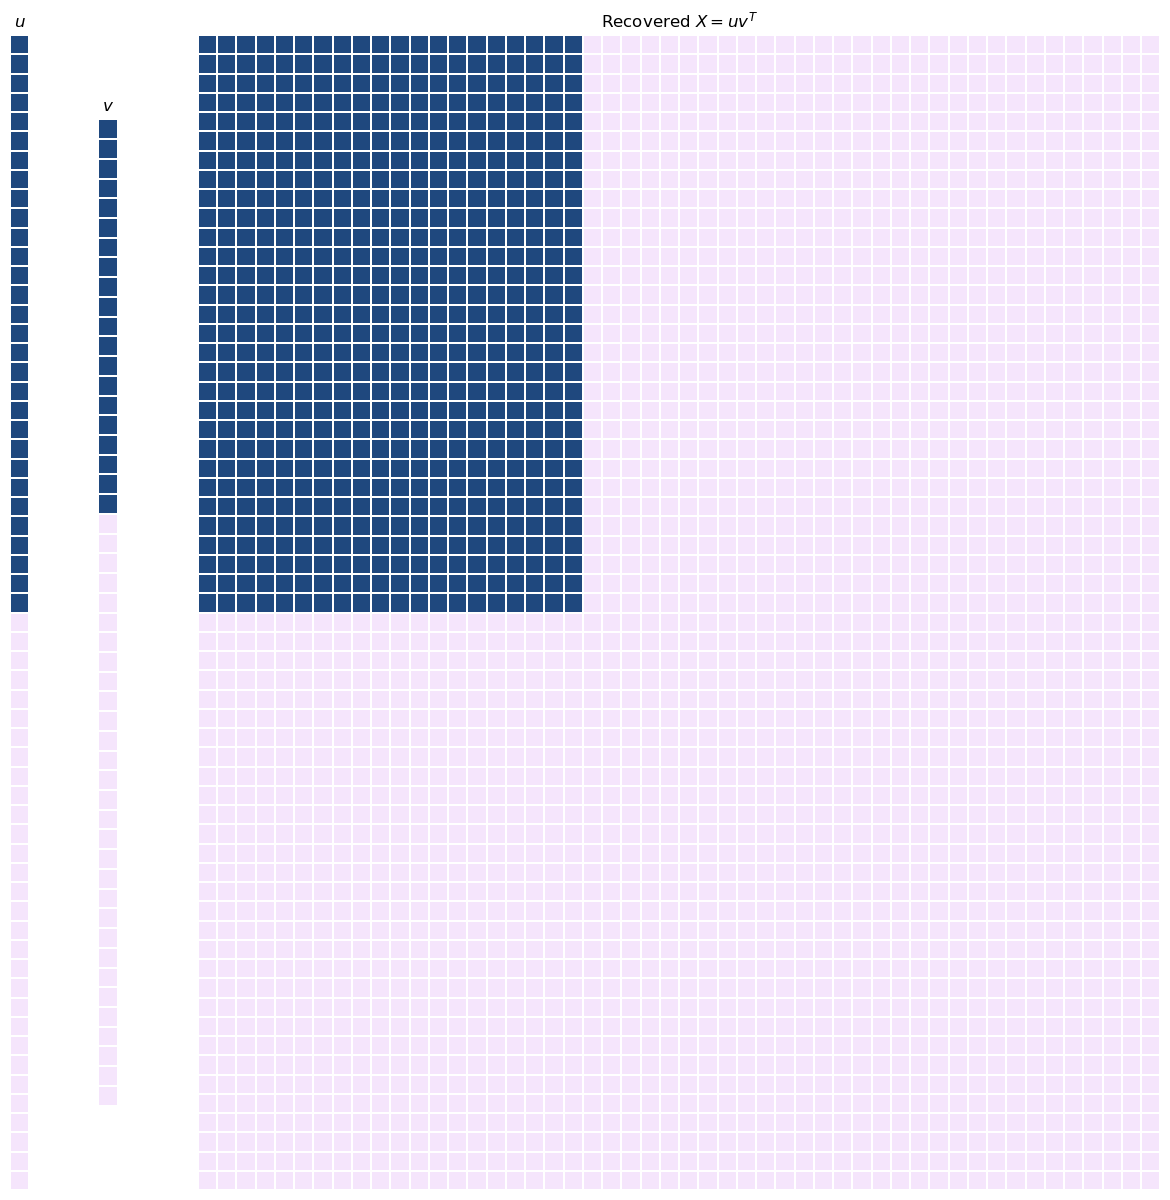

In [297]:
X = np.outer(u,v)

fig, axes = plt.subplots(1,3, width_ratios=[1,1,50])
fig.set_size_inches(15, 15)

plt.subplot(1,3,1)
sns.heatmap(u.reshape(-1,1), linewidth =.01, cbar=False, square=True, cmap=bin_cmap)
axes[0].set_axis_off()
axes[0].set_title("$u$")

plt.subplot(1,3,2)
sns.heatmap(v.reshape(-1,1), linewidth =.01, cbar=False, square=True, cmap=bin_cmap)
axes[1].set_axis_off()
axes[1].set_title("$v$")


plt.subplot(1,3,3)
sns.heatmap(X, linewidth =.01, cbar=False, square=True, cmap=bin_cmap)
axes[2].set_axis_off()
axes[2].set_title("Recovered $X = u v^T$")
plt.show()

### Symmetric Matrices and Dense Subgraphs

``ENSub`` can also be used to solve the **densest subgraph** problem without modification.

To illustrate this process, we first make a random graph containing $60$ nodes with a single dense subgraph with $40$ nodes. We use the same probabilities of edge creation from our previous example.
We sample the random graph using the ``stochastic_block_model`` function from the ``Networkx`` package.

In [363]:
# Size of random matrix.
M = 30

# Size of planted block.
m = 20

# Connectivity probabilities.
p = [[0.75, 0.15], [0.15, 0.25]]

# Sample the graph.
G = nx.stochastic_block_model(sizes=[m, M - m], p=p, seed=42)

# Generate the adjacency matrix.
AG = nx.adjacency_matrix(G).toarray()
np.fill_diagonal(AG, 1)


It is clear from the following visualization that this graph contains a single especially dense subgraph.

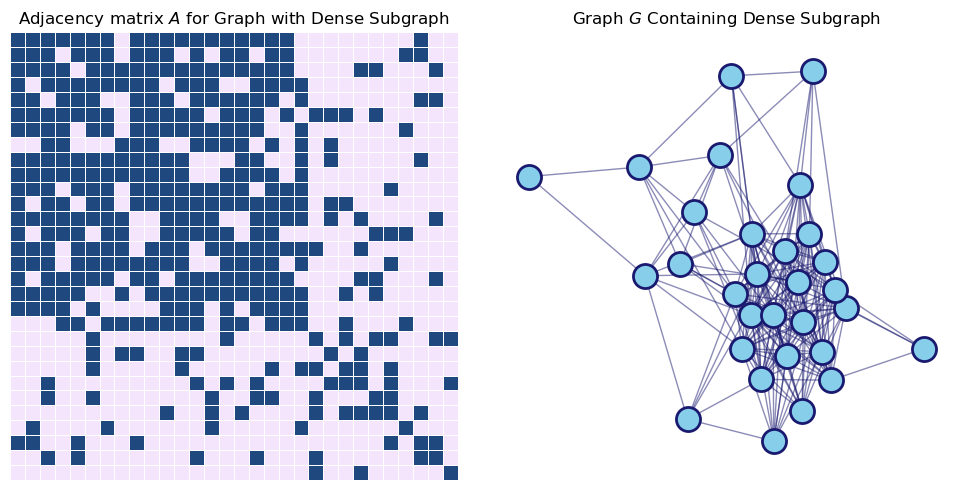

In [420]:
fig, axes = plt.subplots(1,2)
fig.set_size_inches(10, 5)

# Visualize the adjacency matrix.
plt.subplot(1,2,1)
sns.heatmap(AG, linewidth =.5, cbar=False, square=True, cmap=bin_cmap)
axes[0].set_axis_off()
axes[0].set_title("Adjacency matrix $A$ for Graph with Dense Subgraph")

# Visualize the graph
plt.subplot(1,2,2)
posn = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, posn, with_labels=False,
                 node_color="midnightblue",
                 edge_color="midnightblue",
                 alpha=0.5)
nx.draw_networkx_nodes(G, posn, 
                       linewidths=2,
                 node_color="skyblue",
                 edgecolors="midnightblue",
                 )
axes[1].set_axis_off()
axes[1].set_title("Graph $G$ Containing Dense Subgraph")

plt.box(False)
plt.tight_layout()
plt.savefig("DEMO/G.png", transparent = False, bbox_inches="tight")
plt.show()

We can find this subgraph by calling ``ENSub``. Here, we change the optimization parameters from their defaults for illustration purposes. We use $\gamma = m/5 = 8$.

In [421]:
# Set parameters.
my_rho = 40
tol = 1e-5
maxits = 2000
my_alpha = 0.65

m = 20

# Define 
es = ENSub(rho=my_rho, alpha=my_alpha, opt_tol=tol, maxiter=maxits, verbose=True)

gam = m/5
u,v,x, y, fval, its = es.solve(AG, [m, n], gam)
clique = np.argsort(u)[::-1][:m]


+++++++++++++++++++++++++++++++++++++++++++++++++++++++
ENSUB - ADMM for Elastic Net Densest Submatrix
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
M=30, N=30, m=20, n=20, gamma=4.000e+00
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
It 	 | Objective 	 | Primal Gap 	 | Dual 	
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
  5 	 | 2.200e+02 	 | 4.234e-04 	 | 4.776e-02


The ``ENSub`` solver converges to the matrix representation of the planted dense subgraph highlighted in the figure below.

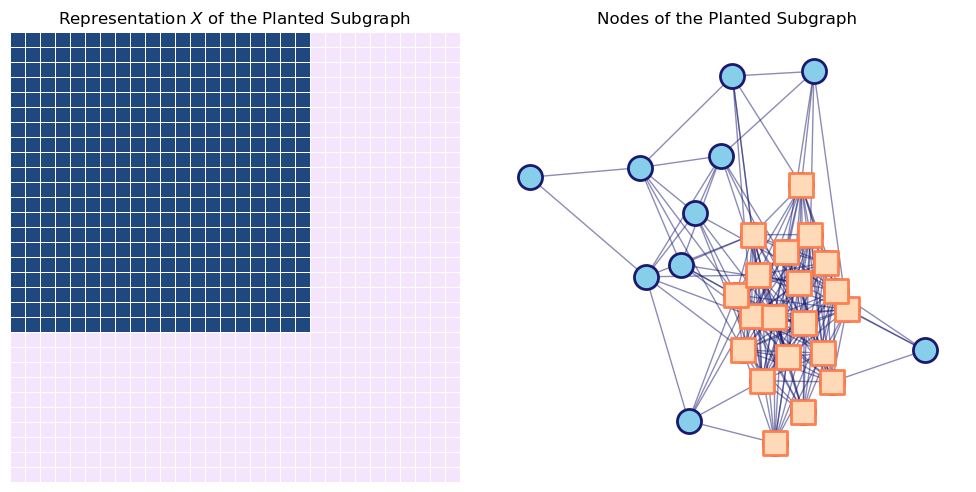

In [422]:
X = np.outer(u,v)

fig, axes = plt.subplots(1,2)
fig.set_size_inches(10, 5)

plt.subplot(1,2,1)
sns.heatmap(X,
                 linewidth =.5, cbar=False, square=True, cmap=bin_cmap)
axes[0].set_axis_off()
axes[0].set_title("Representation $X$ of the Planted Subgraph")

plt.subplot(1,2,2)
nx.draw_networkx(G, posn, with_labels=False,
                 node_color="midnightblue",
                 edge_color="midnightblue",
                 alpha=0.5)
nx.draw_networkx_nodes(G, posn, 
                       linewidths=2,
                 node_color="skyblue",
                 edgecolors="midnightblue",
                 )

nx.draw_networkx_nodes(G, posn,
                       edgecolors="coral",
                       linewidths=2,
                 node_color="peachpuff",
                 node_shape="s",
                 node_size=275,
                 nodelist=clique,
                 )
axes[1].set_axis_off()
axes[1].set_title("Nodes of the Planted Subgraph")

plt.box(False)
plt.tight_layout()

plt.savefig("DEMO/Xgraph.png", transparent = False, bbox_inches="tight")
plt.show()

In [423]:
# Set parameters.
my_rho = 40
tol = 1e-5
maxits = 2000
my_alpha = 0.65

m = 20

# Define 
es = ENSub(rho=my_rho, alpha=my_alpha, opt_tol=tol, maxiter=maxits, symmetric=True, verbose=True)

gam = m/5
u,v, fval, its = es.solve(AG, m, gam)

+++++++++++++++++++++++++++++++++++++++++++++++++++++++
ENSUB - ADMM for Elastic Net Densest Submatrix
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Symmetric -- M=30, m=20, gamma=4.000e+00
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
It 	 | Objective 	 | Primal Gap 	 | Dual 	
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
  5 	 | 1.108e+02 	 | 3.780e-02 	 | 4.592e-02


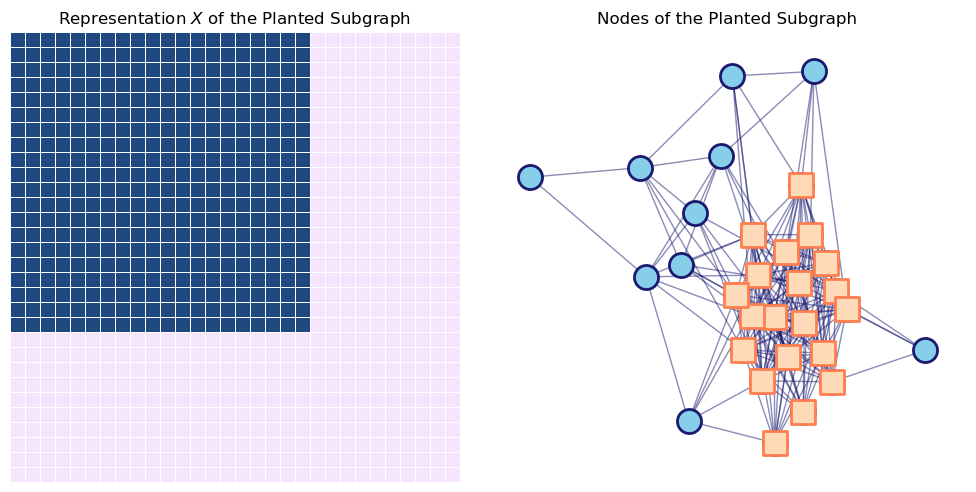

In [425]:
clique = np.argsort(u)[::-1][:m]
X = np.outer(u,v)
fig, axes = plt.subplots(1,2)
fig.set_size_inches(10, 5)

plt.subplot(1,2,1)
sns.heatmap(X,
                 linewidth =.5, cbar=False, square=True, cmap=bin_cmap)
axes[0].set_axis_off()
axes[0].set_title("Representation $X$ of the Planted Subgraph")

plt.subplot(1,2,2)
nx.draw_networkx(G, posn, with_labels=False,
                 node_color="midnightblue",
                 edge_color="midnightblue",
                 alpha=0.5)
nx.draw_networkx_nodes(G, posn, 
                       linewidths=2,
                 node_color="skyblue",
                 edgecolors="midnightblue",
                 )

nx.draw_networkx_nodes(G, posn,
                       edgecolors="coral",
                       linewidths=2,
                 node_color="peachpuff",
                 node_shape="s",
                 node_size=275,
                 nodelist=clique,
                 )
axes[1].set_axis_off()
axes[1].set_title("Nodes of the Planted Subgraph")

plt.box(False)
plt.tight_layout()

### The JAZZ Collaboration Data Set

The following is an example on how one could use the package to analyze the collaboration network found in the JAZZ dataset (see [Community Structure in Jazz. Gleiser and Danon. 2003](https://arxiv.org/abs/cond-mat/0307434)).
This is a social/collaboration network where each pair of musicians are linked if they have performed together. The maximum clique in this network contains 30 musicians.

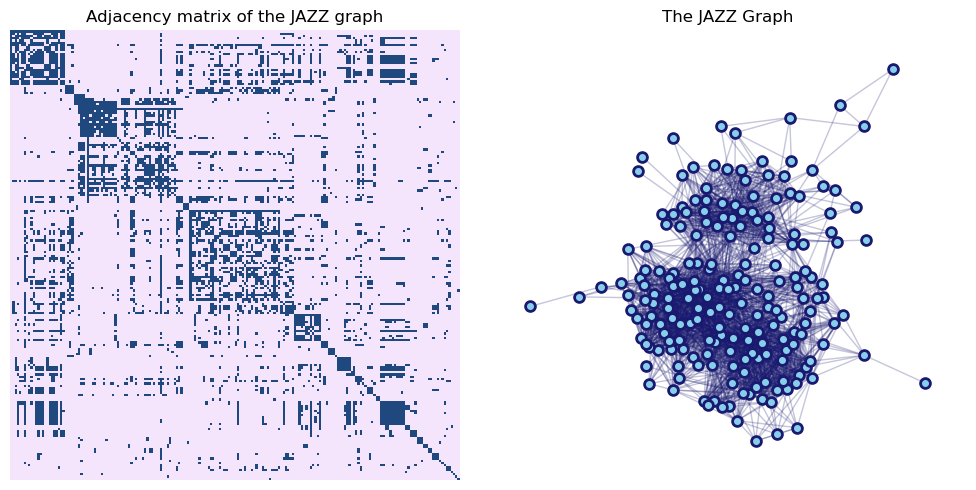

In [428]:
Gjazz = nx.read_adjlist("DEMO/jazz.txt")
Gjazz = nx.convert_node_labels_to_integers(Gjazz, first_label=0, ordering='default', label_attribute=None)

# Generate the adjacency matrix.
Ajazz = nx.adjacency_matrix(Gjazz).toarray()
np.fill_diagonal(Ajazz, 1)

fig, axes = plt.subplots(1,2)
fig.set_size_inches(10, 5)

# Visualize the adjacency matrix.
plt.subplot(1,2,1)
sns.heatmap(Ajazz, linewidth =0, cbar=False, square=True, cmap=bin_cmap)
axes[0].set_axis_off()
axes[0].set_title("Adjacency matrix of the JAZZ graph")

# Visualize the graph
plt.subplot(1,2,2)
posn = nx.kamada_kawai_layout(Gjazz)
# posn = nx.circular_layout(G)
nx.draw_networkx(Gjazz, posn, with_labels=False,
                 node_color="midnightblue",
                 node_size=0,
                 edge_color="midnightblue",
                 alpha=0.25)
nx.draw_networkx_nodes(Gjazz, posn, 
                       linewidths=2,
                 node_color="skyblue",
                 node_size=50,
                 edgecolors="midnightblue",
                 )

axes[1].set_axis_off()
axes[1].set_title("The JAZZ Graph")

plt.box(False)
plt.tight_layout()


plt.savefig("DEMO/Jazz_G.png", transparent = False, bbox_inches="tight")
plt.show()


We are now ready to try to identify the densest submatrix of size 30 in this adjacency matrix. Here, we set $m=n=30$ in our call to `DenSub`.

In [429]:
m = 100
es = ENSub(rho=5, maxiter= 200, verbose=True)

u,v, _,_,_, _ = es.solve(Ajazz, [m, m], gamma = 5)

+++++++++++++++++++++++++++++++++++++++++++++++++++++++
ENSUB - ADMM for Elastic Net Densest Submatrix
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
M=198, N=198, m=100, n=100, gamma=5.000e+00
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
It 	 | Objective 	 | Primal Gap 	 | Dual 	
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
  5 	 | 9.516e+03 	 | 3.116e-01 	 | 5.869e-01
 10 	 | 8.153e+03 	 | 4.686e-01 	 | 7.485e-01
 15 	 | 9.292e+03 	 | 4.622e-01 	 | 5.514e-01
 20 	 | 1.221e+04 	 | 9.431e-01 	 | 1.788e+00
 25 	 | 1.335e+04 	 | 8.329e-01 	 | 1.089e+00
 30 	 | 9.814e+03 	 | 7.187e-01 	 | 8.173e-01
 35 	 | 1.233e+04 	 | 9.350e-01 	 | 1.135e+00
 40 	 | 1.216e+04 	 | 8.379e-01 	 | 7.854e-01
 45 	 | 1.040e+04 	 | 7.675e-01 	 | 1.126e+00
 50 	 | 1.351e+04 	 | 8.969e-01 	 | 1.321e+00
 55 	 | 1.018e+04 	 | 7.500e-01 	 | 7.205e-01
 60 	 | 1.148e+04 	 | 7.848e-01 	 | 1.218e+00
 65 	 | 1.468e+04 	 | 8.910e-01 	 | 1.332e+00
 70 	 | 1.082e+04 	 | 8.233e-01 	 | 8.936e-0

In [430]:
X = np.outer(u,v)
clique = np.argsort(u)[::-1][:m]
print(clique)


[  0 134 125 126 127 128 129 130 131 132 133 135  16 136  15  14  13  12
 144  92 146 147 124 122 149  21  94  95  96 100 101  75 106  23  22  20
 121 111 113  19 115  18 117  17 119 120 148 145 150 169 171 172 173 174
 151 176 177 178   8   7   6   5   4 186 187   3 191   2   1 170 175 168
 159 152  11 154  10 156 167 157 158  81   9 166 163 164 165 139 194 162
  76 161 105  77 188  78 181  48 142 112]


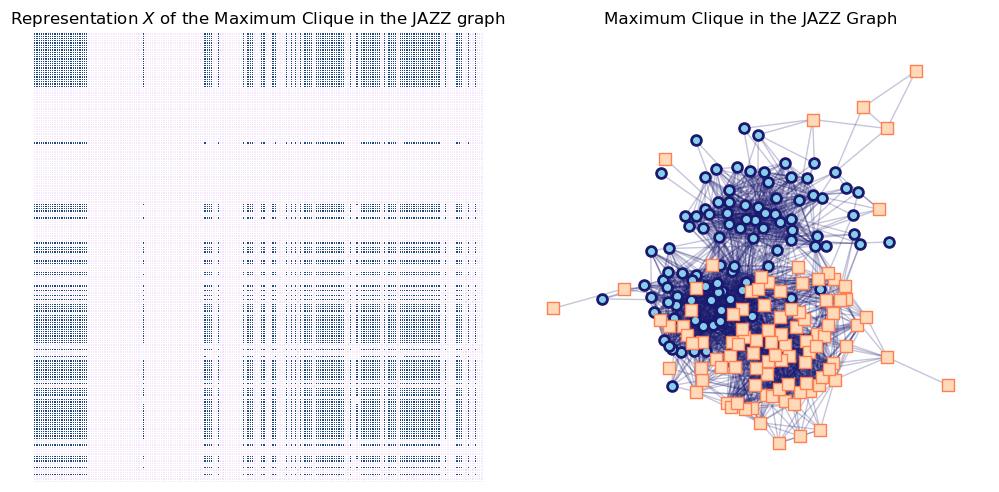

In [431]:
fig, axes = plt.subplots(1,2)
fig.set_size_inches(10, 5)

# Visualize the adjacency matrix.
plt.subplot(1,2,1)
sns.heatmap(X, linewidth =0.5, cbar=False, square=True, cmap=bin_cmap)
axes[0].set_axis_off()
axes[0].set_title("Representation $X$ of the Maximum Clique in the JAZZ graph")

plt.subplot(1,2,2)

nx.draw_networkx(Gjazz, posn, with_labels=False,
                 node_color="midnightblue",
                 edge_color="midnightblue",
                 node_size=0,
                 alpha=0.25)
nx.draw_networkx_nodes(Gjazz, posn, 
                       linewidths=2,
                 node_color="skyblue",
                 edgecolors="midnightblue",
                 node_size=50,
                 )
nx.draw_networkx_nodes(Gjazz, posn,
                       edgecolors="coral",                
                 node_color="peachpuff",
                 node_shape="s",
                 node_size=75,
                 nodelist=clique,
                 )
axes[1].set_axis_off()
axes[1].set_title("Maximum Clique in the JAZZ Graph")

plt.box(False)
plt.tight_layout()
plt.savefig("DEMO/jazz_clique.png", transparent = False, bbox_inches="tight")
plt.show()

In [432]:
# Set parameters.
my_rho = 40
tol = 1e-5
maxits = 2000
my_alpha = 0.65

m = 31

# Define 
es = ENSub(rho=my_rho, alpha=my_alpha, opt_tol=tol, maxiter=maxits, symmetric=True, verbose=True)

gam = m/5
u,v, fval, its = es.solve(Ajazz, m, gam)

+++++++++++++++++++++++++++++++++++++++++++++++++++++++
ENSUB - ADMM for Elastic Net Densest Submatrix
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Symmetric -- M=198, m=31, gamma=6.200e+00
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
It 	 | Objective 	 | Primal Gap 	 | Dual 	
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
  5 	 | 2.476e+02 	 | 1.109e-01 	 | 3.243e-01
 10 	 | 1.692e+02 	 | 8.570e-03 	 | 3.436e-02
 15 	 | 1.716e+02 	 | 1.561e-03 	 | 1.366e-02
 20 	 | 1.726e+02 	 | 5.276e-09 	 | 6.029e-07


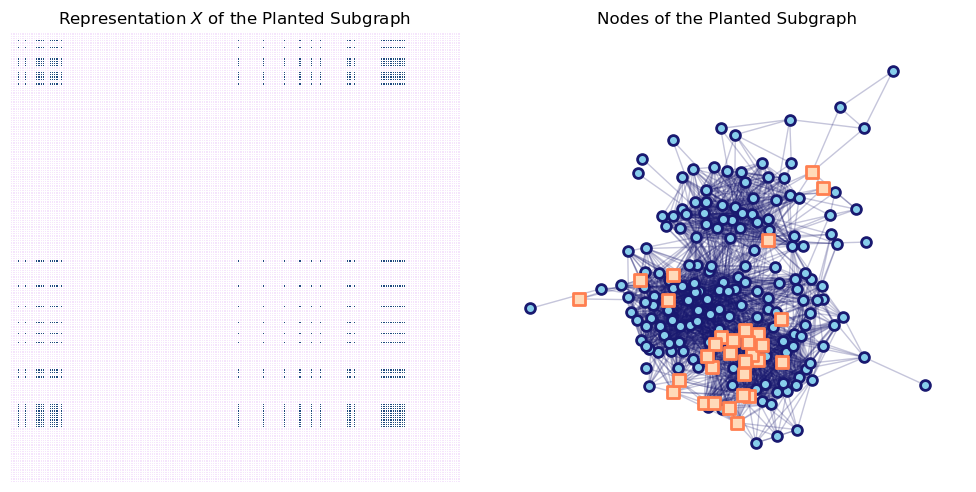

In [435]:
clique = np.argsort(u)[::-1][:m]
X = np.outer(u,v)
fig, axes = plt.subplots(1,2)
fig.set_size_inches(10, 5)

plt.subplot(1,2,1)
sns.heatmap(X,
                 linewidth =.5, cbar=False, square=True, cmap=bin_cmap)
axes[0].set_axis_off()
axes[0].set_title("Representation $X$ of the Planted Subgraph")

plt.subplot(1,2,2)
nx.draw_networkx(Gjazz, posn, with_labels=False,
                 node_color="midnightblue",
                 node_size=0,
                 edge_color="midnightblue",
                 alpha=0.25)
nx.draw_networkx_nodes(Gjazz, posn, 
                       linewidths=2,
                 node_color="skyblue",
                 node_size=50,
                 edgecolors="midnightblue",
                 )


nx.draw_networkx_nodes(Gjazz, posn,
                       edgecolors="coral",
                       linewidths=2,
                 node_color="peachpuff",
                 node_shape="s",
                 node_size=75,
                 nodelist=range(m),
                 )
axes[1].set_axis_off()
axes[1].set_title("Nodes of the Planted Subgraph")

plt.box(False)
plt.tight_layout()